# Detection and Removal of outliers using IQR based filtering

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Loading and visualizing data

In [48]:
df = pd.read_csv('E:/Dataset/placement.csv')

In [4]:
df.sample(5)

,cgpa,placement_exam_marks,placed
460,6.91,4.0,1
158,5.74,50.0,0
456,6.76,12.0,1
149,6.81,58.0,0
679,6.70,35.0,0


Text(0.5, 1.0, 'Placement exam marks column')

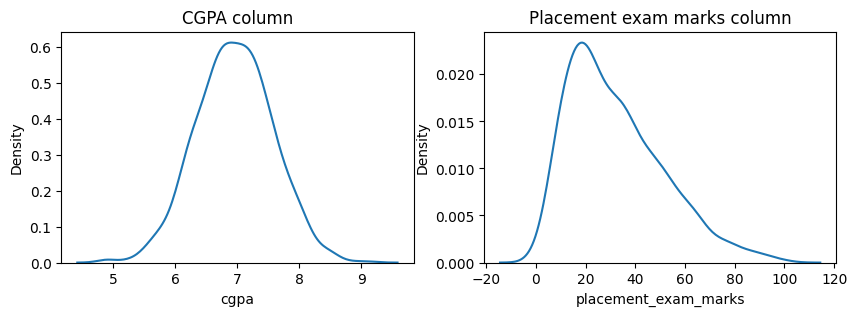

In [69]:
plt.figure(figsize=(10,3))

plt.subplot(121)
sns.kdeplot(df['cgpa'])
plt.title('CGPA column')

plt.subplot(122)
sns.kdeplot(df['placement_exam_marks'])
plt.title('Placement exam marks column')

In [14]:
df['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

In [49]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='placement_exam_marks'>

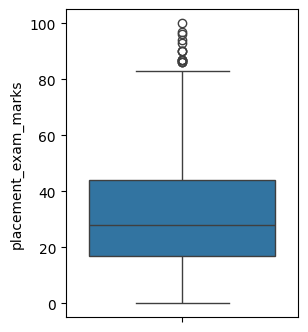

In [50]:
plt.figure(figsize=(3,4))
sns.boxplot(df['placement_exam_marks'])

### Finding IQR and outliers

In [23]:
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

In [26]:
iqr = percentile75 - percentile25
iqr

np.float64(27.0)

In [29]:
upper_limit = percentile75 + 1.5*iqr
lower_limit = percentile25 - 1.5*iqr

print(f'Upper limit: {upper_limit}')
print(f'Lower limit: {lower_limit}')

Upper limit: 84.5
Lower limit: -23.5


In [35]:
# Finding outliers

outliers = df[(df['placement_exam_marks']>upper_limit) | (df['placement_exam_marks']<lower_limit)]

In [36]:
outliers.shape

(15, 3)

### Trimming

In [38]:
new_df = df[(df['placement_exam_marks']>lower_limit) & (df['placement_exam_marks']<upper_limit)]

In [40]:
new_df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [43]:
new_df.shape

(985, 3)

In [55]:
new_df.describe()

,cgpa,placement_exam_marks,placed
count,985.000000,985.000000,985.00000
mean,6.961594,31.339086,0.48934
std,0.614734,17.857633,0.50014
min,4.890000,0.000000,0.00000
25%,6.550000,17.000000,0.00000
50%,6.960000,28.000000,0.00000
75%,7.370000,43.000000,1.00000
max,9.120000,83.000000,1.00000


#### Comparing after trimming

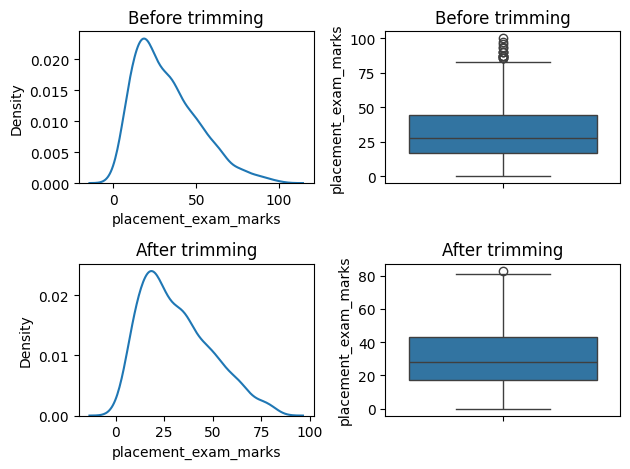

In [64]:
# plt.figure(figsize=(10,8))

plt.subplot(221)
sns.kdeplot(df['placement_exam_marks'])
plt.title('Before trimming')

plt.subplot(222)
sns.boxplot(df['placement_exam_marks'])
plt.title('Before trimming')

plt.subplot(223)
sns.kdeplot(new_df['placement_exam_marks'])
plt.title('After trimming')

plt.subplot(224)
sns.boxplot(new_df['placement_exam_marks'])
plt.title('After trimming')

plt.tight_layout()
plt.show()

### Capping

In [51]:
df['scapped_placement_exam_marks'] = np.where(
    df['placement_exam_marks']>upper_limit,
    upper_limit,
    np.where(
        df['placement_exam_marks']<lower_limit,
        lower_limit,
        df['placement_exam_marks']
    )
)

In [52]:
df.describe()

,cgpa,placement_exam_marks,placed,scapped_placement_exam_marks
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,6.961240,32.225000,0.489000,32.136500
std,0.615898,19.130822,0.500129,18.865419
min,4.890000,0.000000,0.000000,0.000000
25%,6.550000,17.000000,0.000000,17.000000
50%,6.960000,28.000000,0.000000,28.000000
75%,7.370000,44.000000,1.000000,44.000000
max,9.120000,100.000000,1.000000,84.500000


#### Comparing after capping

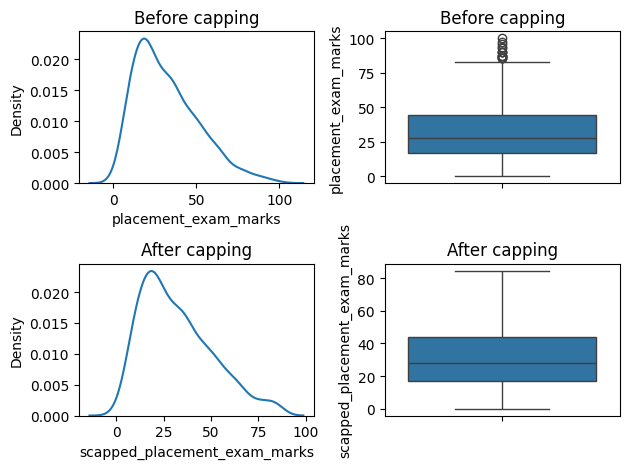

In [67]:
plt.subplot(221)
sns.kdeplot(df['placement_exam_marks'])
plt.title('Before capping')

plt.subplot(222)
sns.boxplot(df['placement_exam_marks'])
plt.title('Before capping')

plt.subplot(223)
sns.kdeplot(df['scapped_placement_exam_marks'])
plt.title('After capping')

plt.subplot(224)
sns.boxplot(df['scapped_placement_exam_marks'])
plt.title('After capping')

plt.tight_layout()
plt.show()